## Лабораторная работа №1
### Предварительный статистический анализ данных
#### Анализ распределений выборок на основе графиков и статистических тестов
##### Задачи исследования

1. Исследовать основные описательные статистики для каждого коэффициента (минимум, максимум, среднее, медиана, стандартное отклонение) с целью ознакомления с особенностями данных и их распределением.
2. Провести графический анализ данных с целью анализа их распределения на
основе построения гистограмм.
---

In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import pyreadstat
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import shapiro, kstest, chisquare, norm

data_path = 'Annual 2005-2011_START.sav'
data, meta = pyreadstat.read_sav(data_path)

display(data.head())

stats = data.describe()
stats.loc['skew'] = data.skew(numeric_only=True)
stats.loc['kurt'] = data.kurt(numeric_only=True)
display(stats.iloc[:, 0:12])
display(stats.iloc[:, 12:23])

,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
0,6095.0,0.942380,0.060563,0.678302,-0.161531,NaN,0.202055,0.165019,0.399033,0.799019,...,1.082798,0.655937,4.454819,3.975687,0.892446,1007.536232,0.076738,0.055049,0.034904,5.0
1,255.0,1.980494,0.274382,0.916775,0.624425,NaN,0.089377,0.220648,0.000000,0.933519,...,1.123828,0.705951,10.618881,12.295547,1.157895,357.294118,0.116068,0.059740,0.025647,5.0
2,114.0,0.374160,0.001494,0.085138,-1.504990,NaN,0.235739,0.508929,0.888889,0.779049,...,1.185374,0.123415,0.794785,6.258929,7.875000,36.894737,-0.584879,0.010563,0.000000,5.0
3,365.0,7.859079,0.831978,2.449864,0.875862,NaN,0.059439,0.030030,0.011111,0.942010,...,1.309449,2.804607,48.363889,26.142643,0.540541,33.676983,0.171731,0.496295,0.312415,5.0
4,168.0,1.779376,0.005596,0.883293,0.527853,NaN,0.135491,0.886686,0.489796,0.887341,...,0.994832,0.473041,5.628827,3.125354,0.555241,19.103896,0.064809,0.025726,0.011839,5.0


,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,k9,k10
count,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,1540.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000
mean,1220.773284,2.002089,0.238018,0.825098,0.038115,0.335777,0.346330,0.238031,0.174212,0.655964,6.862756,0.831359
std,2556.406482,1.690052,0.517697,0.918292,0.625155,0.360196,0.198008,0.213094,0.223266,0.195774,7.943256,0.802107
min,10.000000,0.248322,0.000000,0.008329,-4.569874,-2.599123,0.009944,0.000000,0.000000,0.053766,0.059320,0.040014
25%,229.500000,1.097990,0.017088,0.317674,-0.181377,0.154884,0.185165,0.062932,0.001073,0.522272,2.590124,0.356280
50%,473.000000,1.473859,0.055551,0.538349,0.148620,0.367201,0.319908,0.185185,0.075676,0.681890,4.758963,0.617689
75%,1128.500000,2.238232,0.211538,0.941372,0.422199,0.573384,0.479741,0.361182,0.268773,0.817227,8.245208,0.987389
max,28650.000000,18.020148,7.029135,11.187699,0.935935,0.944507,1.083702,1.000000,1.000000,0.990056,199.605839,11.834268
skew,5.516686,3.385204,4.990825,3.428045,-2.322777,-1.778910,0.561709,1.008406,1.507845,-0.525526,7.700774,3.833633
kurt,39.396740,16.580257,35.883102,17.473216,9.356913,8.247683,-0.265989,0.449773,1.645573,-0.378203,141.337159,27.620585


,k11,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
count,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000
mean,1.325512,1.351127,1.201444,9.944428,13.504512,2.149889,201.286497,0.054974,0.079206,0.065179,8.000000
std,0.537772,0.596442,0.700291,7.636115,13.384226,2.817287,2260.459197,0.110704,0.094002,0.146802,2.000371
min,0.098838,0.230067,0.033180,0.220451,0.347459,0.000000,0.447730,-0.975133,-0.321271,-2.670820,5.000000
25%,1.110017,1.071357,0.672567,4.598417,5.980288,0.734275,10.060489,0.023797,0.017260,0.004226,6.000000
50%,1.237491,1.180362,1.106136,8.169934,9.851228,1.235572,20.099094,0.059466,0.056022,0.044154,8.000000
75%,1.448376,1.356088,1.591163,13.316773,16.690873,2.384732,48.951216,0.103877,0.123064,0.119201,10.000000
max,15.865194,10.809042,4.982852,68.830441,195.041667,31.559748,104151.000000,0.860892,0.635036,0.836596,11.000000
skew,11.443269,4.716121,0.935870,1.874910,4.796901,4.266697,37.327021,-2.693214,1.234058,-4.211790,0.000000
kurt,265.654879,42.161859,1.175882,6.139569,42.230892,26.381324,1668.916385,19.759284,3.253020,68.574551,-1.250093


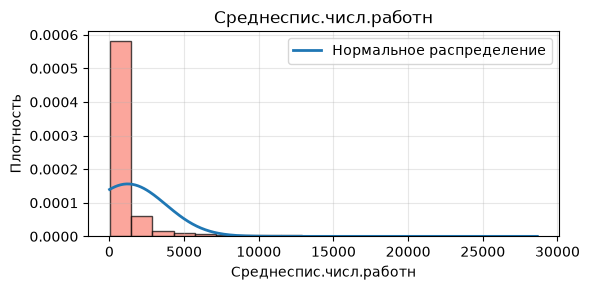

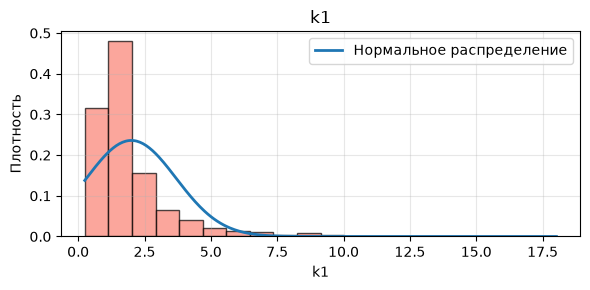

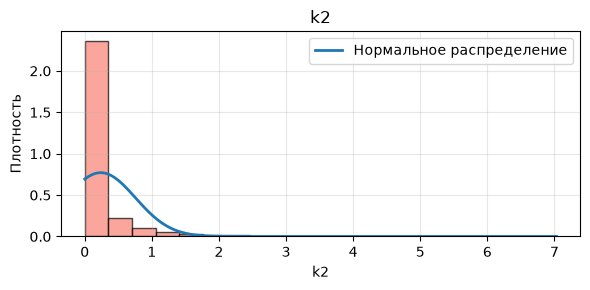

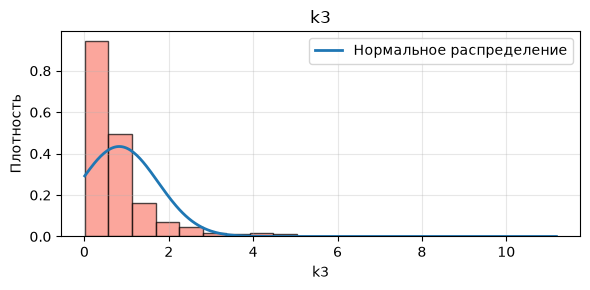

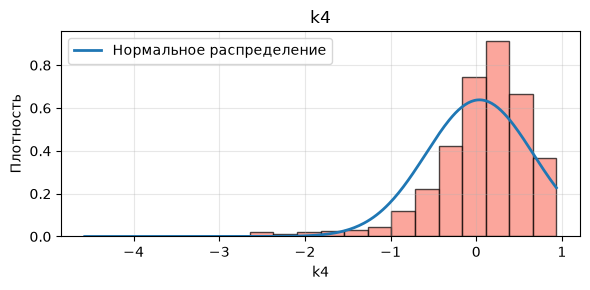

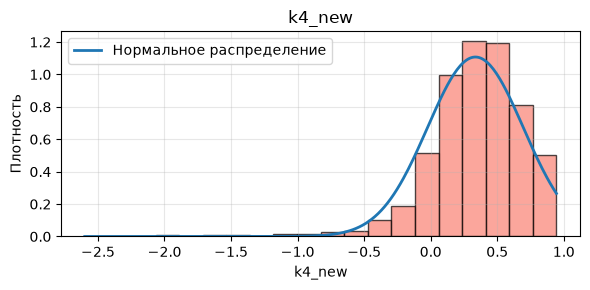

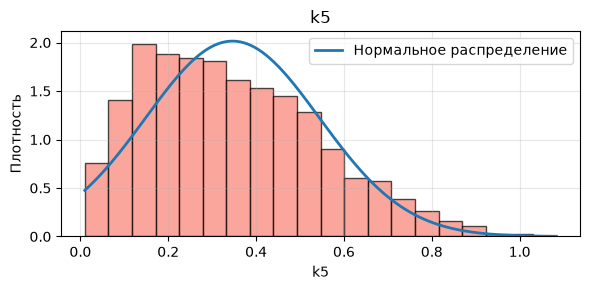

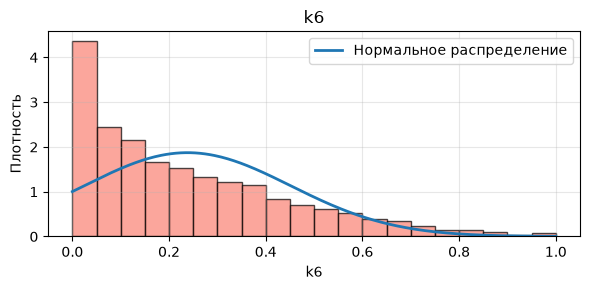

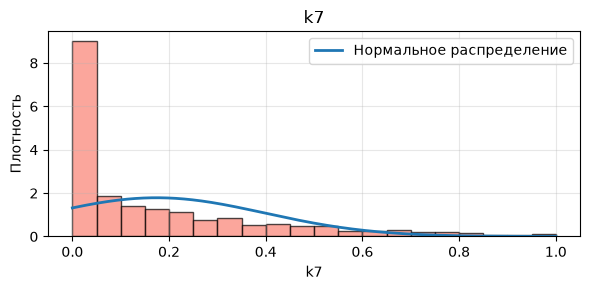

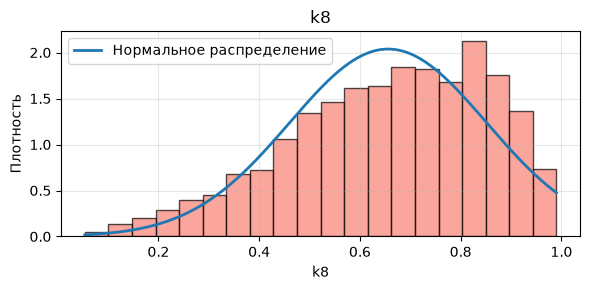

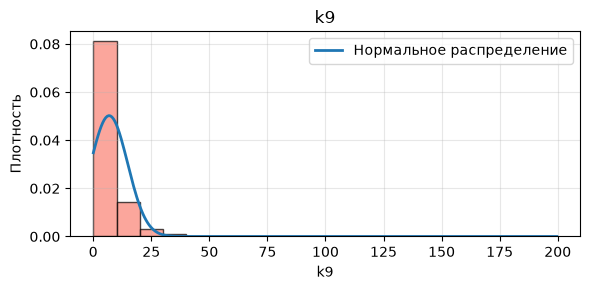

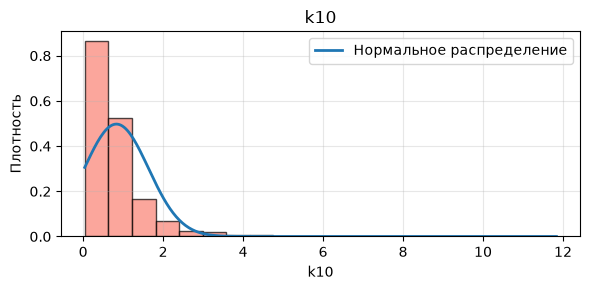

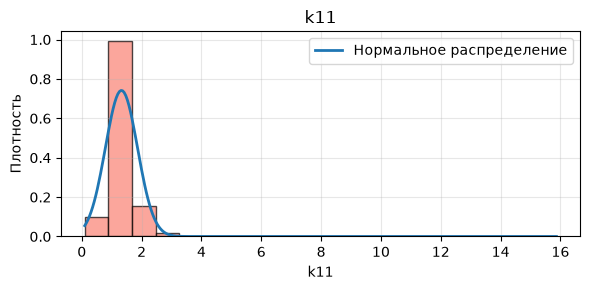

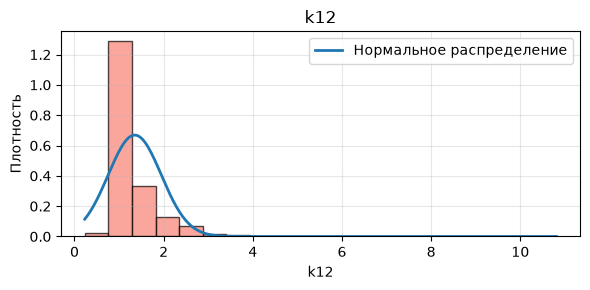

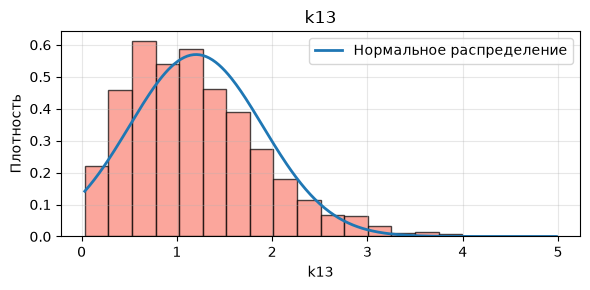

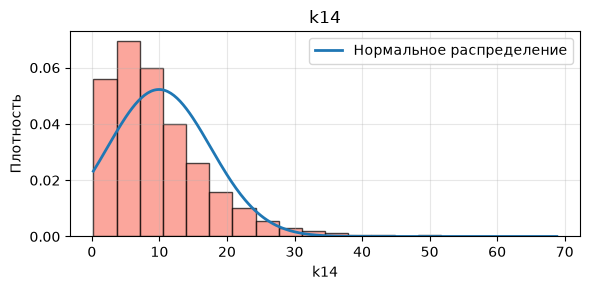

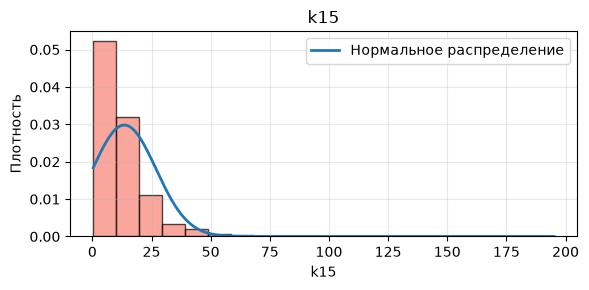

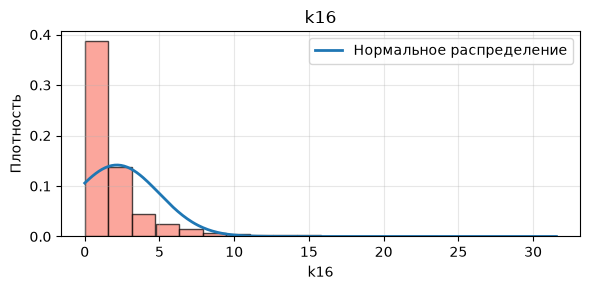

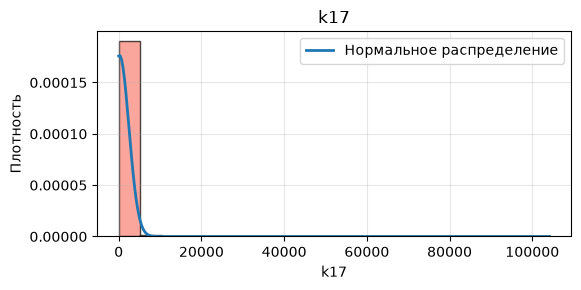

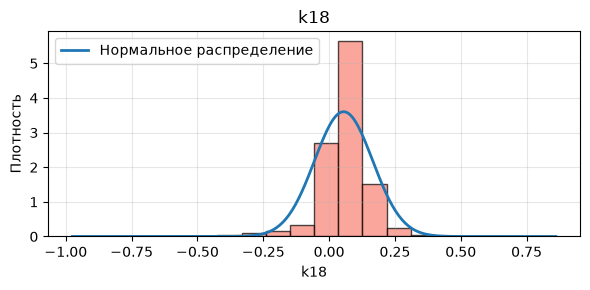

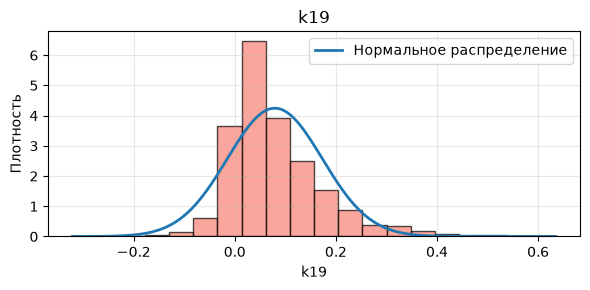

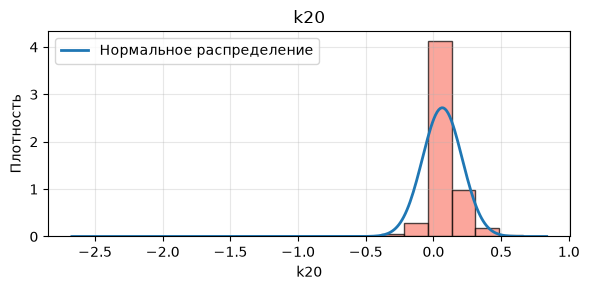

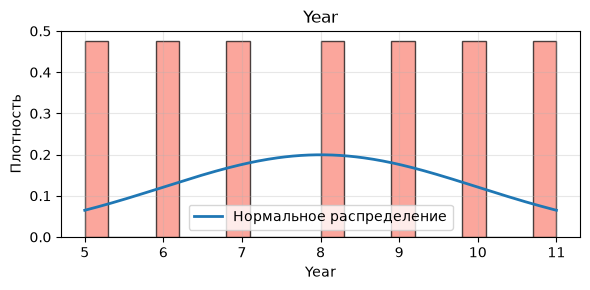

In [53]:
columns = data.select_dtypes(include = ['number']).columns

for column in columns:
    x = data[column].dropna()

    plt.figure(figsize = (6, 3))
    plt.hist(x, bins = 20, density = 'True', color = 'salmon',edgecolor = 'black', alpha = 0.7)

    x_normal = np.linspace(x.min(), x.max(), 300)
    y_normal = norm.pdf(x_normal, loc = x.mean(), scale = x.std())

    plt.plot(x_normal, y_normal, linewidth = 2, label = 'Нормальное распределение')

    plt.title(column)
    plt.xlabel(column)
    plt.ylabel('Плотность')
    plt.grid(True, alpha = 0.3)
    plt.legend()
    plt.tight_layout()

    plt.show()

1. Выводы относительно области значений анализируемых коэффициентов:
    - Область значений существенно различается
    - Часть ограничена от 0 до 1 **(k5, k6, k7, k8)**
    - Часть имеет и отрицательные значения **(k4, k4_new, k18, k19, k20)**
    - Коэффиценты отличаются диапазоном (**Среднеспис.числ.работн** от 0 до 30000, а **k20** например от -2 до 1)
2. Выводы относительно разброса значений для отдельных коэффициентов:
    - Разброс также довольно неоднороден
    - **Среднеспис.числ.работн**(*2556.406482*) и **k17**(*2260.459197*) имеют наибольшее стандартное отклонение. Также слегка выделяются **k9**(*7.943256*), **k14**(*7.636115*) и **k15**(*13.384226*)
    - Наименьший разброс у **k19**(*0.094002*)
3. Выводы относительно близости средних значений и медиан рассматриваемых коэффициентов:
    - Правосторонняя ассиметрия (*mean > median*) замечена у большинства коэффицентов. Больше всего у **k17**(*201.286497 > 20.099094*)
    - Левосторонняя ассиметрия (*mean < median*) замечена **k4, k4_new, k8 и k18**
    - Наиболее симметричны **Year, k5 и k6**
4. Выводы относительно свойств распределения коэффициентов, в частности относительно нормальности распределения:
    - Гипотеза о нормальности отвергается для большинства коэффицентов
    - Большинство коэффицентов сильно скошены
    - **Year** имеет равномерное распределение
    - Больше всего близки к нормальному распределению **k18, k19 и k20**
5. Выводы относительно наличия в выборках аномальных и экстремальных наблюдений:
    - Аномальные наблюдения присутствуют почти у всех коэффицентов
    - Наибольшие правосторонние выбросы у **k14, k15 и k17**
    - Наибольшие левосторонние выбросы у **k4_new, k18 и k20**

#### Анализ аномальных наблюдений
##### Задачи исследования
1. Исследовать возможность применения ящичных диаграмм, теста Хампеля и правила шести сигм для анализа экстремальных аномальных наблюдений в исследуемых данных. Проанализировать влияние ассиметричности распределений на результаты анализа
2. Осуществить коррекцию границ интервалов для указанных тестов с учетом экономической интерпретации результатов анализа.
---

1. Исследование возможности применения тестов и влияние асимметрии:
    - Метод построения ящичных диаграмм проблематичен, так как у многих коэффицентов длинные хвосты и большая ассиметрия. Из-за этого много большое количество верных данных может быть отмечено как выбросы
    - Тест Хампеля хорошо применим. Он является устойчивым к выброс, так как опирается на медиану и медиану абсолютных отклонений
    - Правило шести сигм не подходит, так как этот тест предпологает нормальность распределения. У нас же на нормальные похожи лишь пара коэффицентов из 23

2. Осуществить коррекцию границ интервалов для указанных тестов с учетом
экономической интерпретации результатов анализа
    - В следующей части задания будем применять тест Хампеля и там подкорректируем значение

##### Задачи исследования
3. Провести графический анализ данных с целью выявления аномальных наблюдений на основе построения ящичных диаграмм.
4. На основании условия ниже или «правила шести сигм» определить экстремальные наблюдения в выборке. Множитель в условии ниже подобрать таким образом, чтобы экстремальными признавалось не более 5-8% наблюдений
5. Провести цензурирование и нормировку данных.
$$[x_{med} - 5.2 \cdot x_{mad}, \; x_{med} + 5.2 \cdot x_{mad}]$$
---

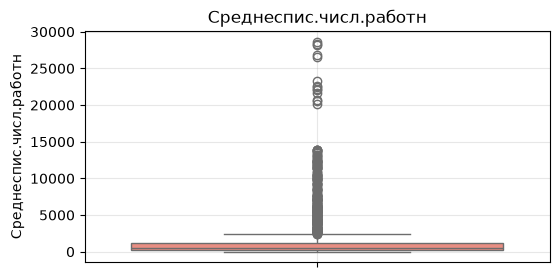

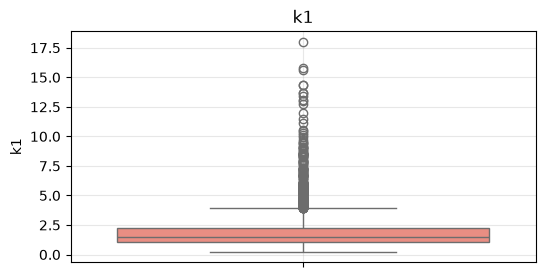

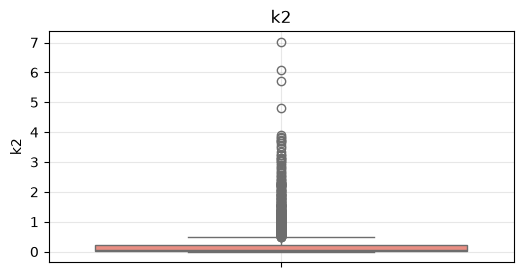

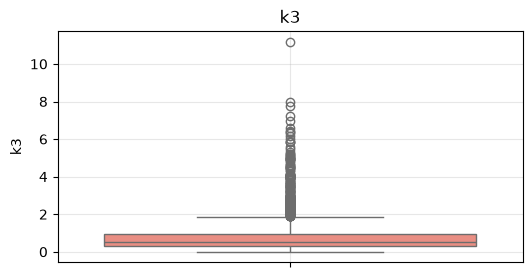

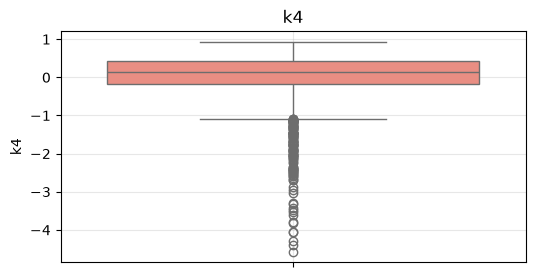

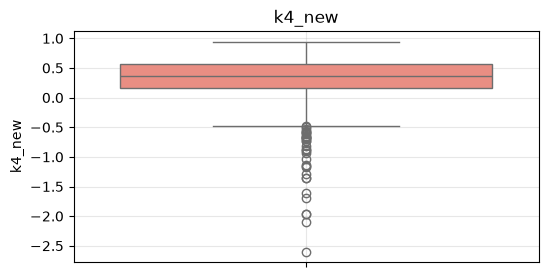

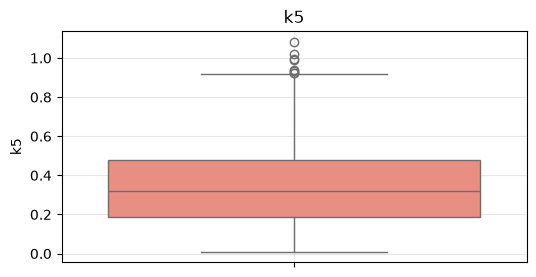

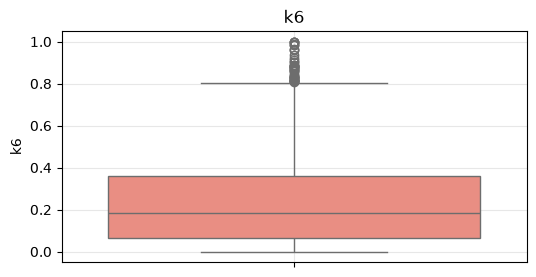

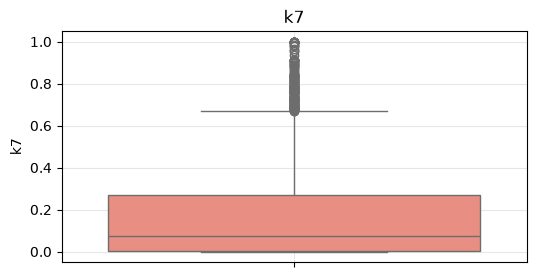

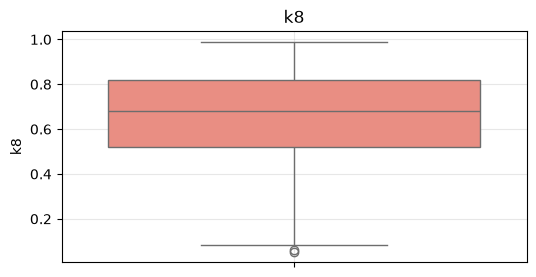

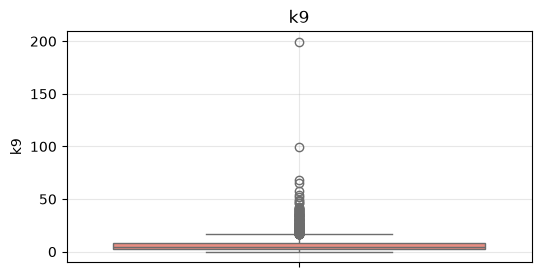

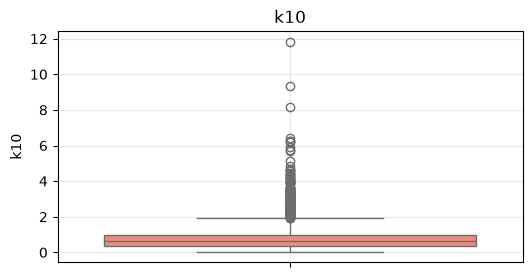

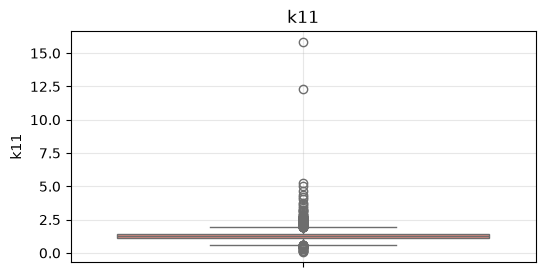

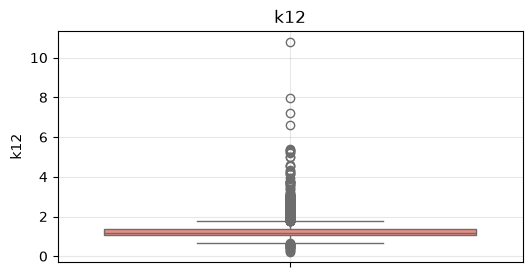

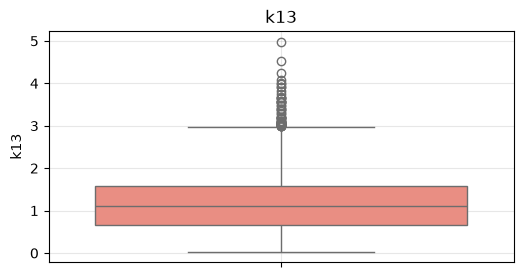

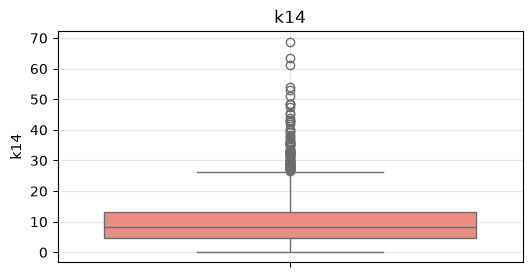

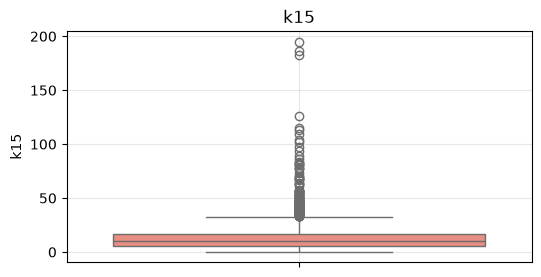

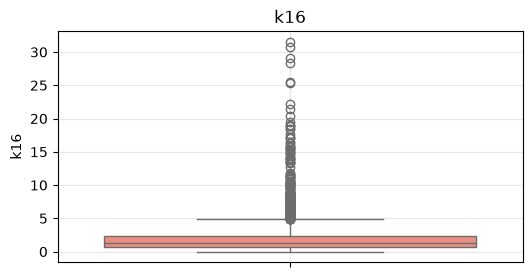

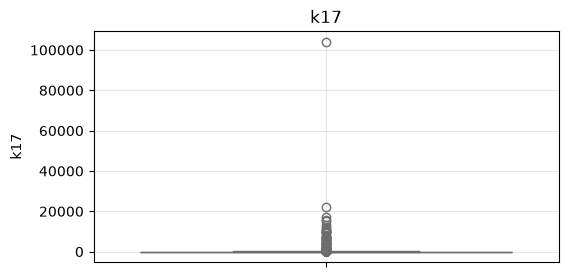

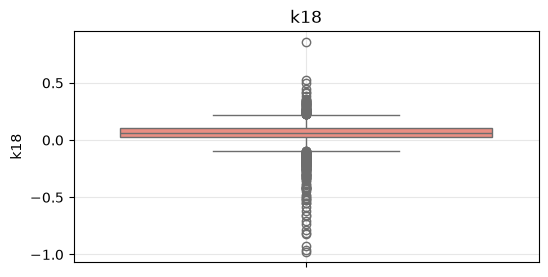

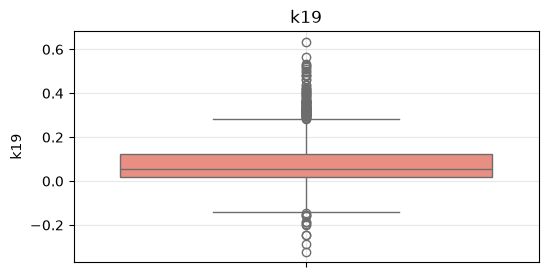

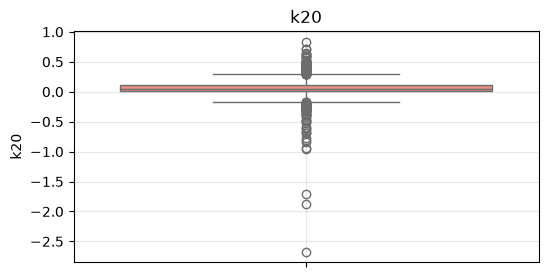

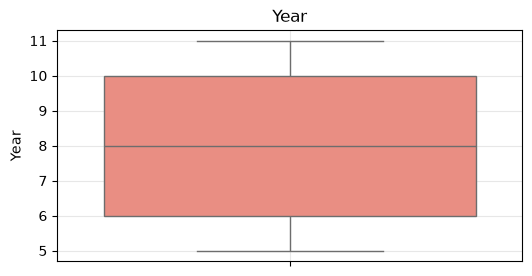

In [45]:
columns = data.select_dtypes(include = ['number']).columns

for column in columns:
    plt.figure(figsize = (6, 3))
    sns.boxplot(y = data[column], color = 'salmon')
    plt.title(column)
    plt.grid(True, alpha = 0.3)
    plt.show()

Построенные ящичные диагрммы показали, что для большинства характеристик характерна правая ассиметрия. Также замечено большое количество выбросов и сжатость самого ящика. Это говорит о нахождения в зоне выбросов более 5-8% данных

In [ ]:
def hampel_test(data, k = 5.2):
    clean_data = data.dropna()
    med = clean_data.median()
    mad = (clean_data - med).abs().median()
    lower_bound = med - k * mad
    upper_bound = med + k * mad

    return lower_bound, upper_bound

В качестве коэффицента для теста Хампеля будем использовать k = 6

In [24]:
def censored_stats(column, data, censored_data):
    outliers_count = ((data != censored_data) & data.notna()).sum()
    outliers_percent = round(outliers_count / len(censored_data) * 100, 2)
    print(f"{column}: {outliers_count}, {outliers_percent}%")

data_censored = data.copy()
columns = data_censored.select_dtypes(include = ['number']).columns

for column in columns:
    lower_bound, upper_bound = hampel_test(data_censored[column], 6)
    data_censored[column] = data_censored[column].clip(lower_bound, upper_bound)
    censored_stats(column, data[column], data_censored[column])

Cреднеспис.числ.работн: 253, 9.39%
k1: 195, 7.24%
k2: 465, 17.25%
k3: 195, 7.24%
k4: 72, 2.67%
k4_new: 15, 0.56%
k5: 0, 0.0%
k6: 0, 0.0%
k7: 248, 9.2%
k8: 0, 0.0%
k9: 134, 4.97%
k10: 117, 4.34%
k11: 95, 3.53%
k12: 312, 11.58%
k13: 8, 0.3%
k14: 41, 1.52%
k15: 113, 4.19%
k16: 240, 8.91%
k17: 356, 13.21%
k18: 109, 4.04%
k19: 64, 2.37%
k20: 153, 5.68%
Year: 0, 0.0%


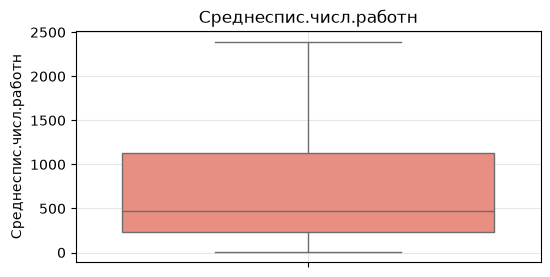

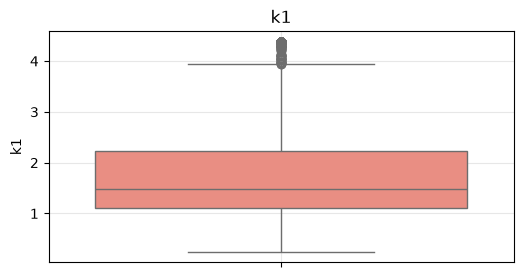

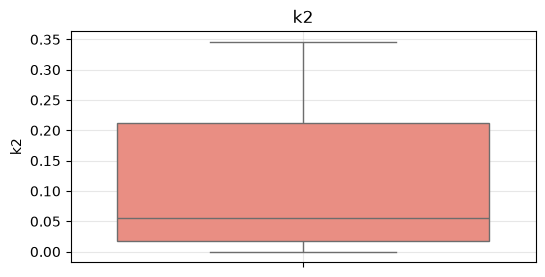

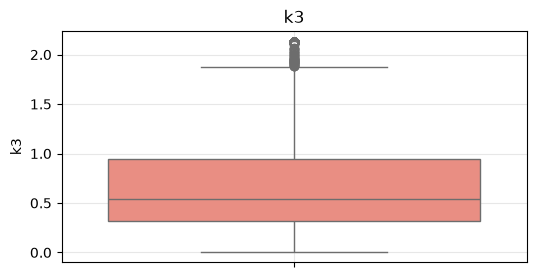

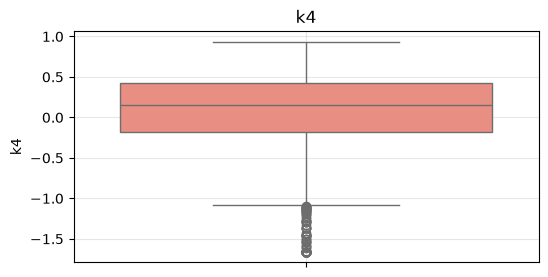

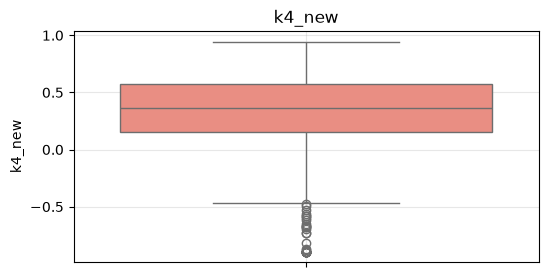

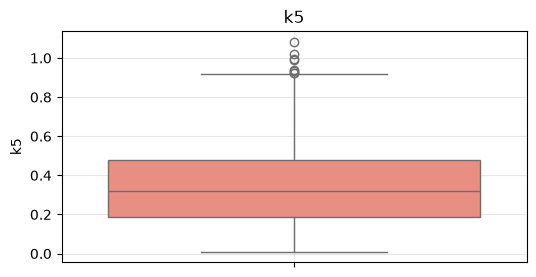

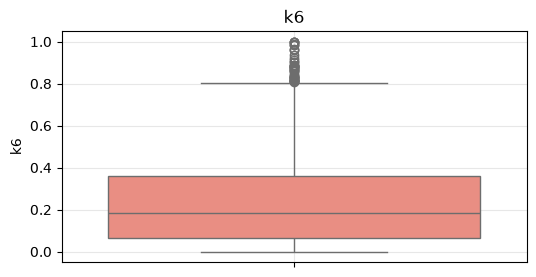

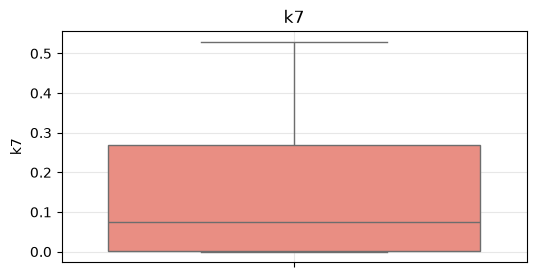

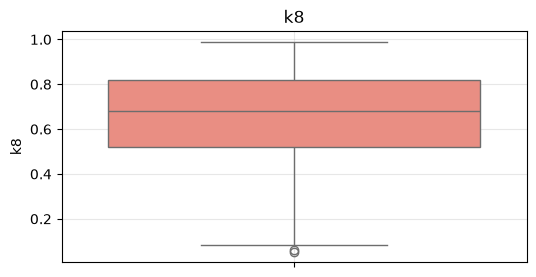

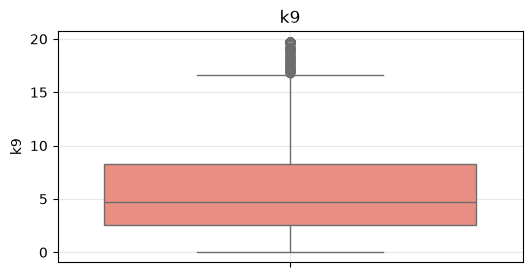

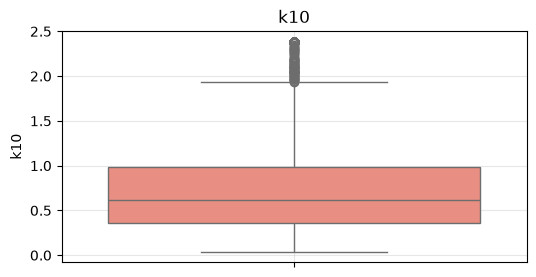

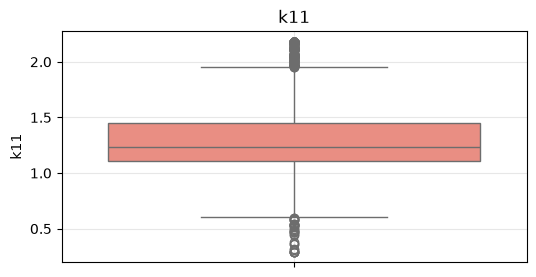

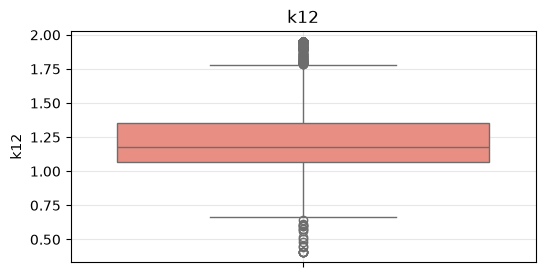

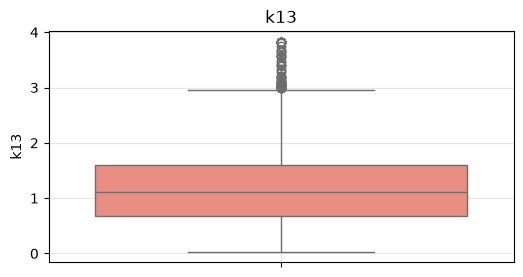

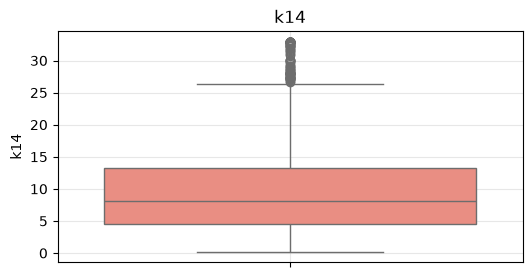

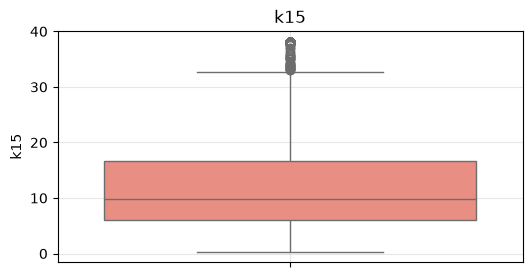

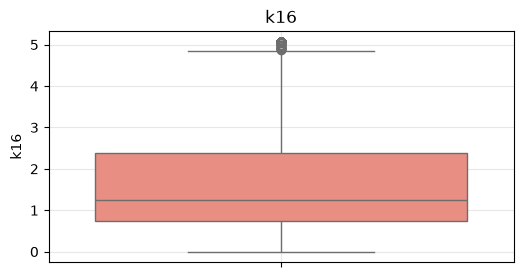

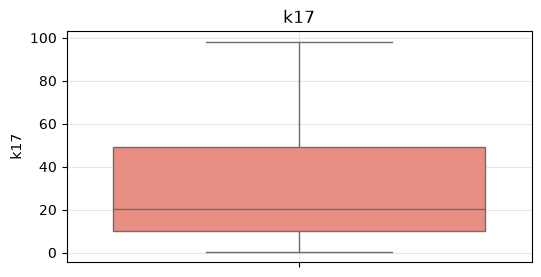

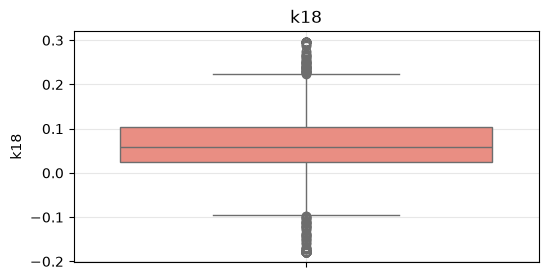

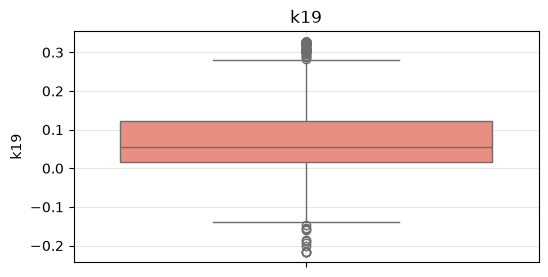

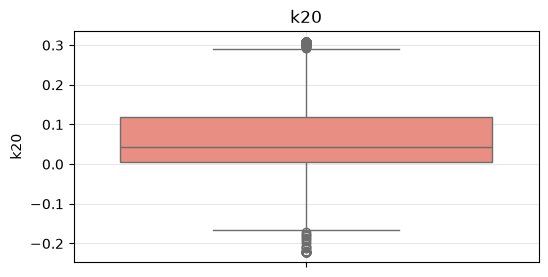

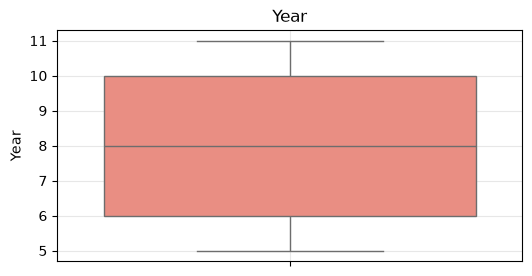

In [46]:
columns = data_censored.select_dtypes(include = ['number']).columns

for column in columns:
    plt.figure(figsize = (6, 3))
    sns.boxplot(y = data_censored[column], color = 'salmon')
    plt.title(column)
    plt.grid(True, alpha = 0.3)
    plt.show()

После цензурирования ящичные диаграммы улучшились, но все равно присутствует много выбросов

In [67]:
from scipy.stats import shapiro, kstest, chisquare, norm

normality = pd.DataFrame(index = ['Шапиро-Уилк', 'Колмогоров-Смирнов', 'Хи-квадрат'])

for column in columns:
    x = data_censored[column].dropna()

    shapiro_p = shapiro(x).pvalue

    mean = x.mean()
    std = x.std()
    ks_p = kstest(x, norm(loc = mean, scale = std).cdf).pvalue

    borders = norm.ppf(np.linspace(0, 1, 11), loc = mean, scale = std)
    observed, _ = np.histogram(x, bins = borders)
    expected = np.full(10, len(x) / 10)

    chi_p = chisquare(observed, expected, ddof = 2).pvalue

    normality[column] = [shapiro_p, ks_p, chi_p]

pd.set_option('display.max_columns', None)
display(normality.style.format('{:.10f}'))

,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,k9,k10,k11,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
Шапиро-Уилк,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000
Колмогоров-Смирнов,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0136162869,0.0000000139,0.0000000000,0.0000000000,0.0000000097,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000215,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000
Хи-квадрат,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0082690977,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000


In [48]:
data_scaled = data_censored.copy()
columns = data_scaled.select_dtypes(include = ['number']).columns
scaler = StandardScaler()
data_scaled[columns] = scaler.fit_transform(data_scaled[columns])

stats = data_scaled.describe()
stats.loc['skew'] = data_scaled.skew(numeric_only=True)
stats.loc['kurt'] = data_scaled.kurt(numeric_only=True)
display(stats.iloc[:, 0:12])
display(stats.iloc[:, 12:23])

,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,k9,k10
count,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,1.540000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03
mean,2.175131e-17,-3.902053e-16,2.109218e-17,2.109218e-17,2.636522e-18,-1.384174e-16,-1.160070e-16,-5.800349e-17,7.909567e-17,-1.898296e-16,1.252348e-16,-2.109218e-17
std,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000325e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00
min,-1.075328e+00,-1.487543e+00,-9.361103e-01,-1.257229e+00,-3.211102e+00,-3.726654e+00,-1.699168e+00,-1.117230e+00,-8.655652e-01,-3.076549e+00,-1.229376e+00,-1.281791e+00
25%,-7.632956e-01,-6.877491e-01,-8.017670e-01,-7.185560e-01,-4.504411e-01,-5.631786e-01,-8.140866e-01,-8.218504e-01,-8.596689e-01,-6.830136e-01,-7.321544e-01,-7.334399e-01
50%,-4.171458e-01,-3.339428e-01,-4.993660e-01,-3.342864e-01,1.666184e-01,7.741264e-02,-1.334687e-01,-2.480376e-01,-4.495986e-01,1.324537e-01,-3.060470e-01,-2.802029e-01
75%,5.146866e-01,3.855626e-01,7.269918e-01,3.675115e-01,6.781820e-01,6.994992e-01,6.738908e-01,5.780298e-01,6.118006e-01,8.238722e-01,3.788885e-01,3.607903e-01
max,2.312249e+00,2.403382e+00,1.786548e+00,2.438996e+00,1.638814e+00,1.819231e+00,3.724643e+00,3.576410e+00,2.046201e+00,1.706832e+00,2.638299e+00,2.783788e+00
skew,1.167067e+00,1.186020e+00,8.882415e-01,1.235913e+00,-1.166080e+00,-8.626462e-01,5.617094e-01,1.008406e+00,9.553723e-01,-5.255255e-01,1.299573e+00,1.310690e+00
kurt,2.619528e-01,4.956844e-01,-8.216753e-01,5.649129e-01,1.666001e+00,1.449034e+00,-2.659888e-01,4.497728e-01,-4.922471e-01,-3.782033e-01,8.862909e-01,1.113713e+00


,k11,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
count,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2695.000000
mean,4.640279e-16,-4.851201e-16,1.581913e-16,3.691131e-17,-8.436871e-17,-1.054609e-17,5.536697e-17,-7.382262e-17,-1.054609e-16,5.273044e-17,0.000000
std,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186
min,-2.937181e+00,-2.722244e+00,-1.678395e+00,-1.362203e+00,-1.350942e+00,-1.233241e+00,-1.061297e+00,-2.937425e+00,-3.343331e+00,-2.843064e+00,-1.500000
25%,-5.571740e-01,-6.361616e-01,-7.589365e-01,-7.400161e-01,-7.315125e-01,-7.257940e-01,-7.584424e-01,-4.489572e-01,-6.878768e-01,-6.204490e-01,-1.000000
50%,-1.855506e-01,-2.921870e-01,-1.354506e-01,-2.324402e-01,-3.058339e-01,-3.793547e-01,-4.421717e-01,-9.028743e-03,-2.460082e-01,-2.256871e-01,0.000000
75%,4.292432e-01,2.623301e-01,5.620331e-01,4.990171e-01,4.463067e-01,4.148133e-01,4.668274e-01,5.387305e-01,5.182437e-01,5.162815e-01,1.000000
max,2.566079e+00,2.137870e+00,3.781663e+00,3.288346e+00,2.806591e+00,2.271964e+00,2.019147e+00,2.919368e+00,2.851315e+00,2.391690e+00,1.500000
skew,6.620095e-01,9.851584e-01,8.707259e-01,1.195513e+00,1.281266e+00,1.184637e+00,1.074561e+00,-4.611130e-01,8.254364e-01,3.058632e-01,0.000000
kurt,6.676226e-01,3.037984e-01,7.751260e-01,1.274781e+00,1.059699e+00,2.359757e-01,-2.672049e-01,1.867975e+00,9.549785e-01,9.281417e-01,-1.250093


После масштабирования у коэффцентов дисперсия и срденее стали 1 и 0

## Корреляционный анализ
#### Задачи исследования
1. Получить матрицу парных коэффициентов корреляции для всех имеющихся
показателей.
2. Выявить переменные, имеющие наиболее тесные взаимосвязи, а также
проанализировать знаки показателей корреляции.
3. Выделить переменные, которые возможно исключить из дальнейшего анализа в
силу существования тесной связи с другой/ими переменной/ыми

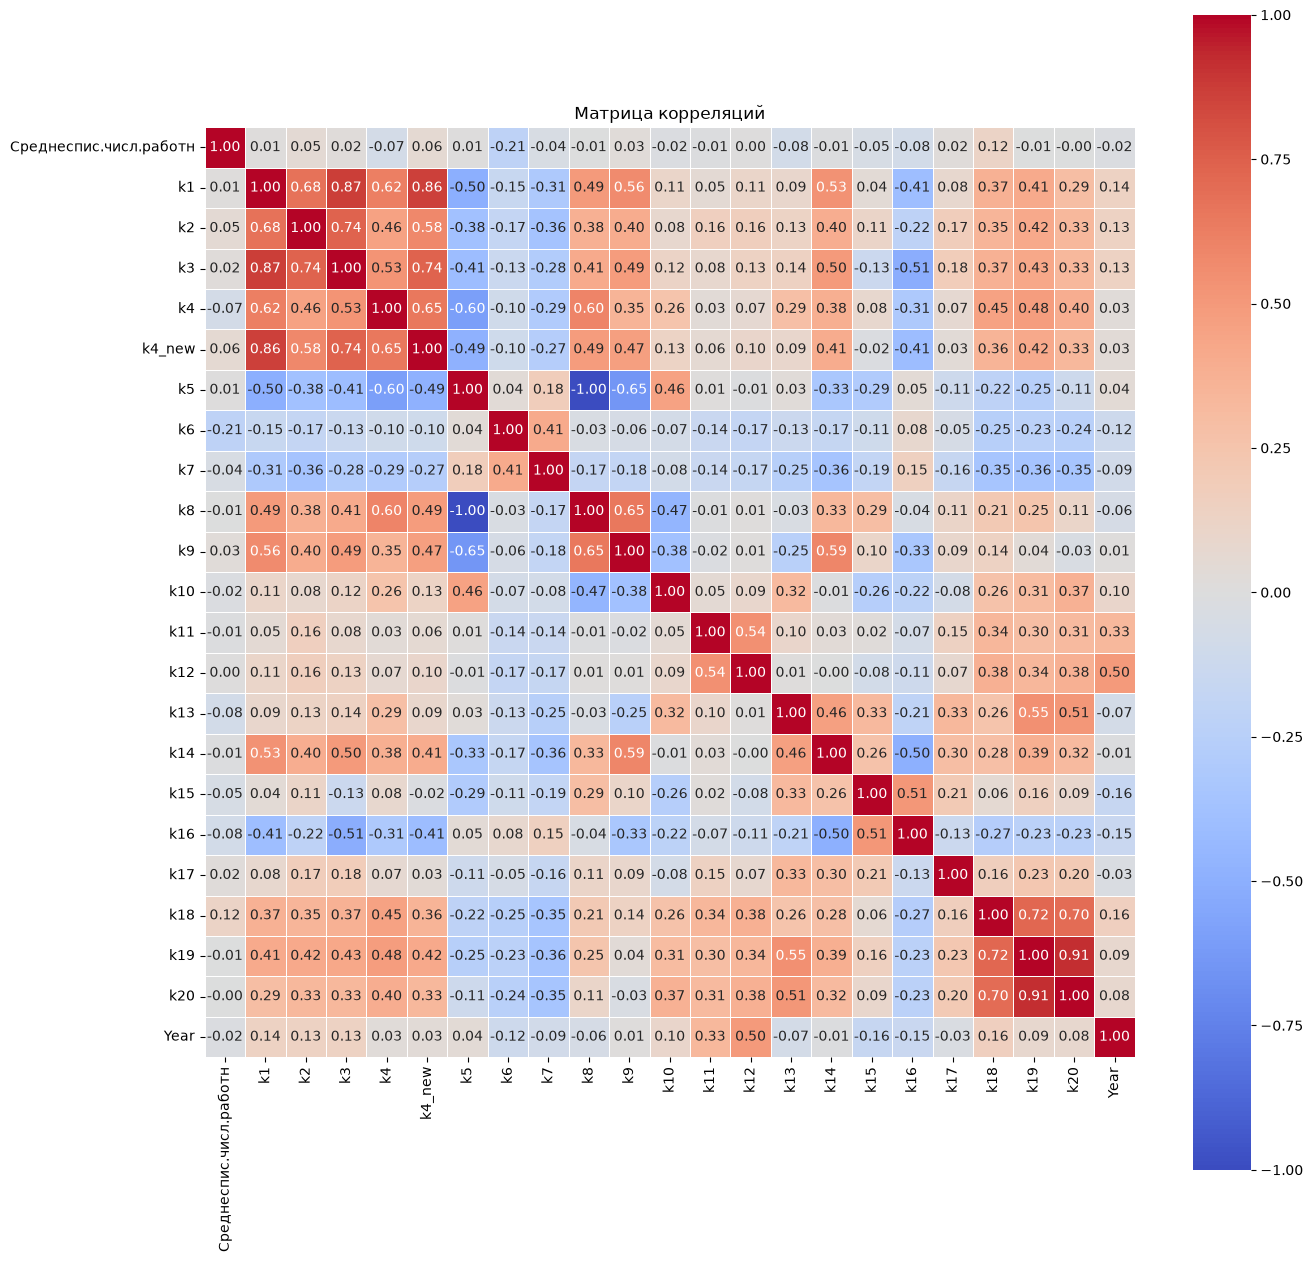

In [42]:
plt.figure(figsize = (15, 15))
sns.heatmap(data_scaled.corr(), annot = True, fmt = '.2f', vmin = -1, vmax = 1, square = True, linewidths = 0.5, cmap = 'coolwarm')
plt.title('Матрица корреляций')
plt.show()

Выводы по матрице корреляций:
- Сильная положительная корреляция у **k1, k2, k3, k4, k4_new**, а также у **k18, k19 и k20**
- Сильная отрицательная корреляция у **k5, k8**
- Практически отсутствует связь у **Среднеспис.числ.работн** со всеми переменными и у **Year**